In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper")

In [5]:
import pandas as pd

df = pd.read_csv("../../../datasets/nurse/raw/nurse_no_features.csv", low_memory=False)

In [7]:
df.head()

,X,Y,Z,EDA,HR,TEMP,id,datetime,label
0,-13.0,-61.0,5.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.000000000,2.0
1,-20.0,-69.0,-3.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.031249920,2.0
2,-31.0,-78.0,-15.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.062500096,2.0
3,-47.0,-65.0,-38.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.093750016,2.0
4,-67.0,-57.0,-53.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.124999936,2.0


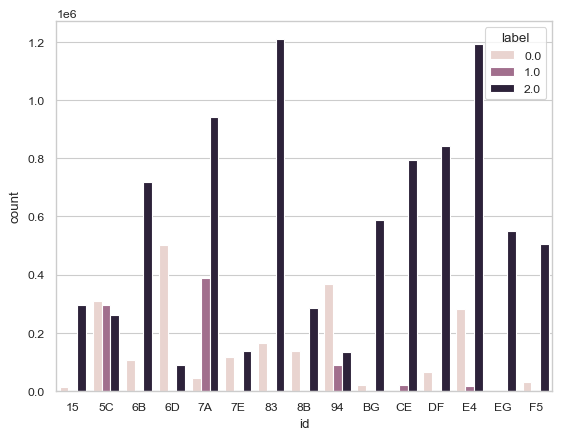

In [6]:
sns.countplot(x=df["id"], hue=df["label"])
plt.show()

## Confusion Matrix Centralized Learning

In [1]:
from pymongo.synchronous.collection import Collection
from pymongo import MongoClient

client = MongoClient("localhost", 27017)

db = client["mth-nurse"]
collection: Collection = db["centralized"]

In [25]:
document = collection.find_one({"_id": "30e027c38a0957d3aff858dd6583bd2396d37b2d35b743194682d7368c427473"})

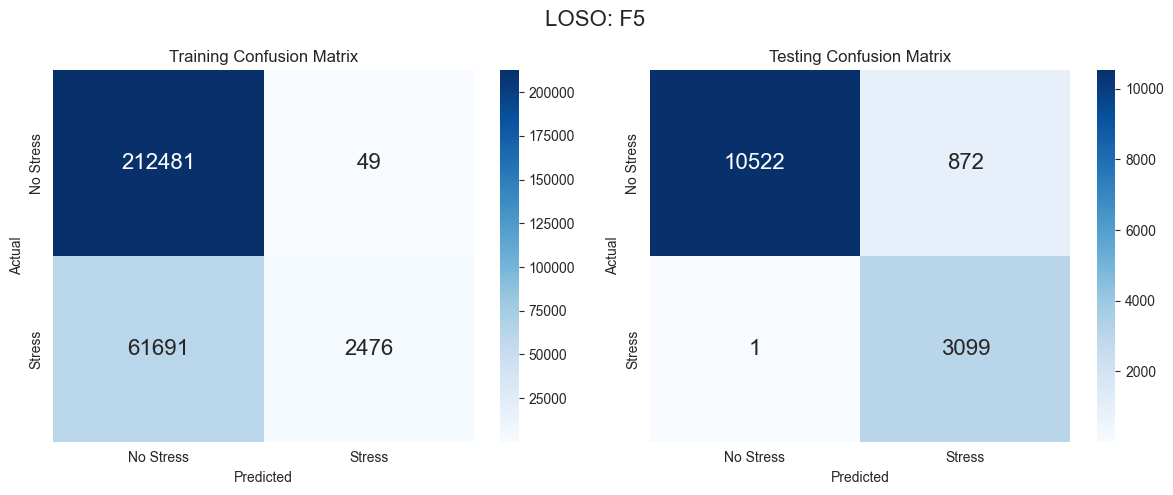

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

training_tp = 0
training_fp = 0
training_tn = 0
training_fn = 0

testing_tp = 0
testing_fp = 0
testing_tn = 0
testing_fn = 0

first_run = document["training_runs"][0]
training_matrix = first_run["scores"]["training_set"]["confusion_matrix"]
# Assemble the confusion matrix from tp, tn, fp, fn
training_tp += training_matrix["tp"]
training_fp += training_matrix["fp"]
training_tn += training_matrix["tn"]
training_fn += training_matrix["fn"]

training_conf_matrix = np.array([
    [training_tp, training_fp],  # First row: actual negatives
    [training_tn, training_fn]   # Second row: actual positives
])

testing_matrix = first_run["scores"]["testing_set"]["confusion_matrix"]
# Assemble the confusion matrix from tp, tn, fp, fn
testing_tp += testing_matrix["tp"]
testing_fp += testing_matrix["fp"]
testing_tn += testing_matrix["tn"]
testing_fn += testing_matrix["fn"]

testing_conf_matrix = np.array([
    [testing_tp, testing_fp],  # First row: actual negatives
    [testing_tn, testing_fn]   # Second row: actual positives
])


labels = ["No Stress", "Stress"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(training_conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0], annot_kws={"size": 16})
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Training Confusion Matrix')

sns.heatmap(testing_conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[1], annot_kws={"size": 16})
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Testing Confusion Matrix')
fig.suptitle(f"LOSO: {first_run['participant_leave_out']}", fontsize=16)
plt.tight_layout()
plt.savefig("../../results/centralized/plots/with_features/dataset_2_nn_c_with_cm.png", dpi=600, bbox_inches="tight")
plt.show()

## Confusion Matrix Individual Learning

In [15]:
from pymongo.synchronous.collection import Collection
from pymongo import MongoClient

client = MongoClient("localhost", 27017)

db = client["mth-nurse"]
collection: Collection = db["individual"]

In [16]:
document = collection.find_one({"_id": "33101df0aea971dd403199d7b2df93c3f1b0f271fe68e5bf404e63229135b03a"})

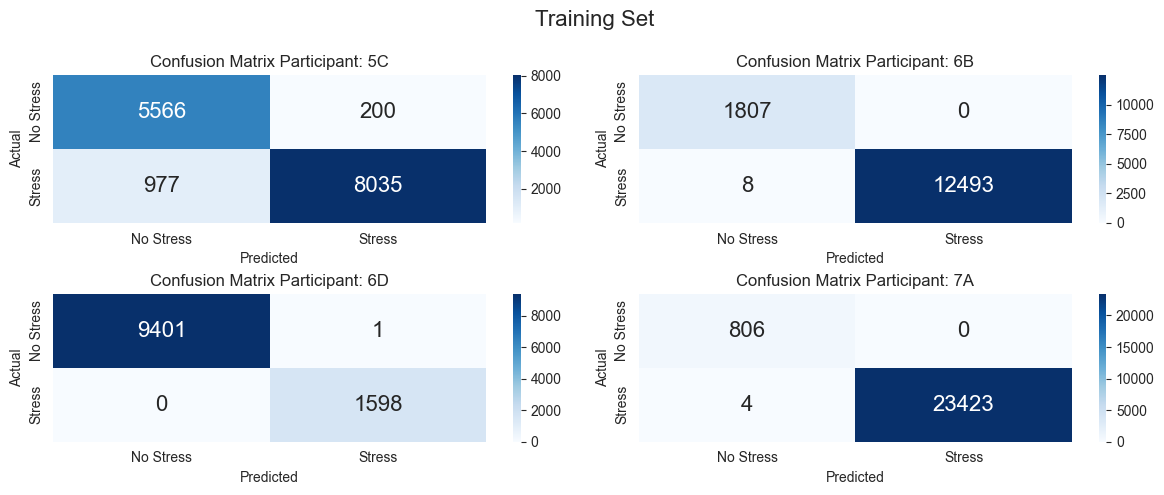

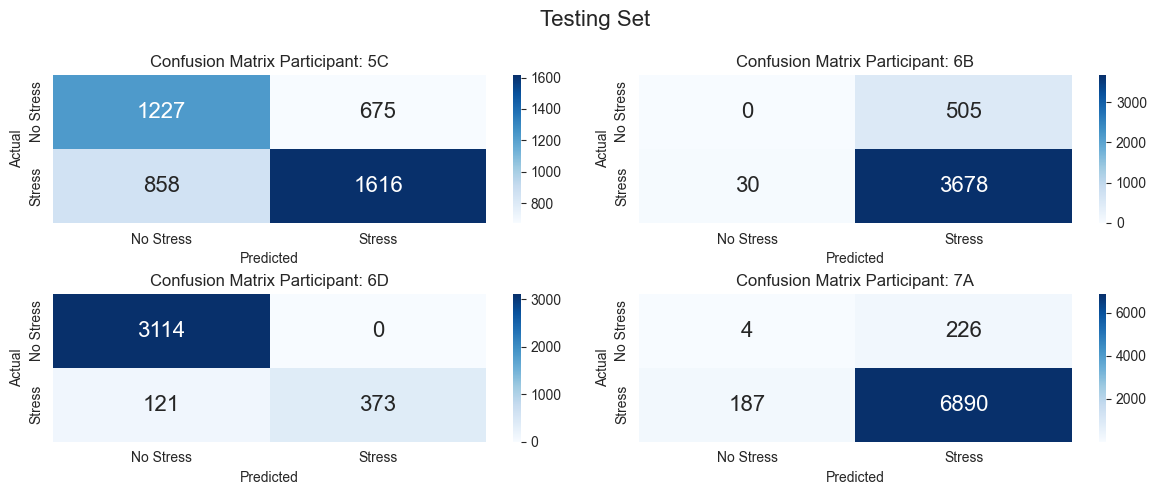

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 5))

for idx, participant in enumerate(document["participants"][0:4]):

    if idx == 0:
        ax = axes[0][0]
    elif idx == 1:
        ax = axes[0][1]
    elif idx == 2:
        ax = axes[1][0]
    elif idx == 3:
        ax = axes[1][1]
    else:
        raise Exception('Index out of range')

    name = participant["participant"]
    matrix = participant["scores"]["training_set"]["confusion_matrix"]

    tp = matrix["tp"]
    fp = matrix["fp"]
    tn = matrix["tn"]
    fn = matrix["fn"]

    conf_matrix = np.array([
        [tn, fp],  # First row: actual negatives
        [fn, tp]   # Second row: actual positives
    ])

    labels = ["No Stress", "Stress"]

    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax, annot_kws={"size": 16})

    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix Participant: {name}')

plt.tight_layout()
fig.suptitle(f"Training Set", fontsize=16)
fig.subplots_adjust(top=0.85)
plt.savefig("../../results/individual/plots/with_features/dataset_2_lr_i_with_cm_train.png", dpi=600, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 5))

for idx, participant in enumerate(document["participants"][0:4]):

    if idx == 0:
        ax = axes[0][0]
    elif idx == 1:
        ax = axes[0][1]
    elif idx == 2:
        ax = axes[1][0]
    elif idx == 3:
        ax = axes[1][1]
    else:
        raise Exception('Index out of range')

    name = participant["participant"]
    matrix = participant["scores"]["testing_set"]["confusion_matrix"]

    tp = matrix["tp"]
    fp = matrix["fp"]
    tn = matrix["tn"]
    fn = matrix["fn"]

    conf_matrix = np.array([
        [tn, fp],  # First row: actual negatives
        [fn, tp]   # Second row: actual positives
    ])

    labels = ["No Stress", "Stress"]

    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax, annot_kws={"size": 16})

    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix Participant: {name}')

plt.tight_layout()
fig.subplots_adjust(top=0.85)
fig.suptitle(f"Testing Set", fontsize=16)
plt.savefig("../../results/individual/plots/with_features/dataset_2_lr_i_with_cm_test.png", dpi=600, bbox_inches="tight")
plt.show()

## Confusion Matrix Federated Learning

In [4]:
from enums.Dataset import Dataset
from pymongo.synchronous.collection import Collection
from pymongo import MongoClient

client = MongoClient("localhost", 27017)

dataset = Dataset.NURSE

db = client["mth-nurse"]
collection: Collection = db["federated"]

In [19]:
document = collection.find_one({"_id": "d4c0a8c95408b6ebbf70b853f223a3a31d47a33f895119114876eb9de7a260c3"})

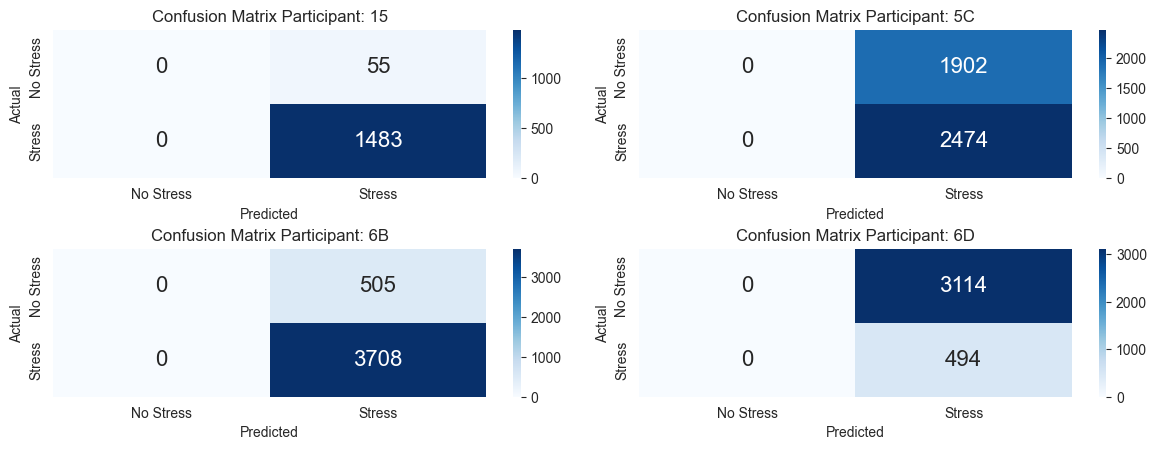

In [20]:
from copy import deepcopy
from collections import OrderedDict
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 5))

clients: dict = deepcopy(document["training_runs"][0]["clients"])
del clients["server"]
# Sort clients by name
if dataset == Dataset.STRESS:
    sorted_clients = OrderedDict(sorted(clients.items(), key=lambda item: int(item[0])))
else:
    sorted_clients = OrderedDict(sorted(clients.items(), key=lambda item: item[0]))

for idx, (client_name, client_data) in enumerate(sorted_clients.items()):
    if idx == 0:
        ax = axes[0][0]
    elif idx == 1:
        ax = axes[0][1]
    elif idx == 2:
        ax = axes[1][0]
    elif idx == 3:
        ax = axes[1][1]
    elif idx == 4:
        break
    else:
        raise Exception('Index out of range')

    matrix = list(client_data["round"].values())[-1]["scores"]["testing_set"]["confusion_matrix"]

    tp = matrix["tp"]
    fp = matrix["fp"]
    tn = matrix["tn"]
    fn = matrix["fn"]

    conf_matrix = np.array([
        [tn, fp],  # First row: actual negatives
        [fn, tp]   # Second row: actual positives
    ])

    labels = ["No Stress", "Stress"]

    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax, annot_kws={"size": 16})

    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix Participant: {client_name}')

plt.tight_layout()
fig.subplots_adjust(top=0.85)
plt.savefig("../../results/federated/plots/with_features/dataset_2_lr_f_with_cm.png", dpi=600, bbox_inches="tight")
plt.show()

## Confusion Matrix Fine Tuning

In [18]:
from pymongo.synchronous.collection import Collection
from pymongo import MongoClient

client = MongoClient("localhost", 27017)
db = client["mth-nurse"]
collection: Collection = db["federated_fine_tuned"]

In [25]:
document = collection.find_one({"_id": "170e083b41881e0114732a37b7c7292149589cad5c8a1d26be65b283c0575113"})

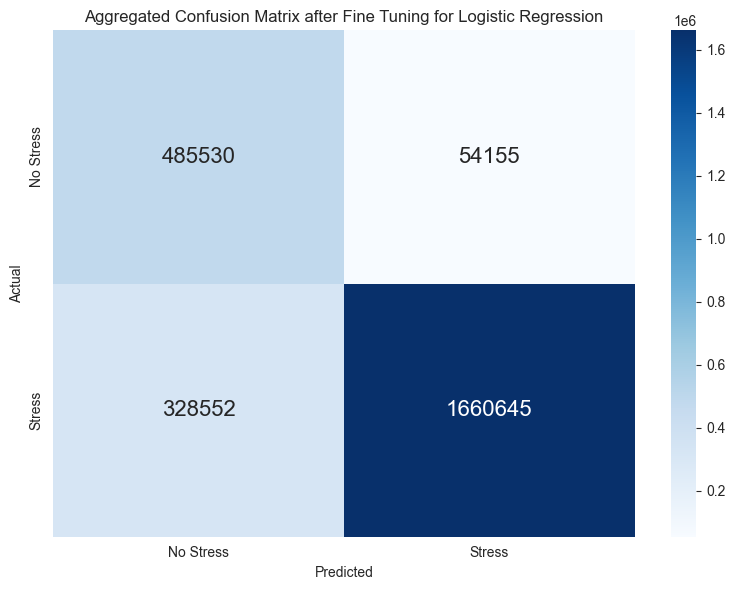

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tp = 0
fp = 0
tn = 0
fn = 0
for participant in document["participants"]:
    matrix = participant["scores"]["testing_set"]["confusion_matrix"]
    # Assemble the confusion matrix from tp, tn, fp, fn
    tp += matrix["tp"]
    fp += matrix["fp"]
    tn += matrix["tn"]
    fn += matrix["fn"]

conf_matrix = np.array([
    [tn, fp],  # First row: actual negatives
    [fn, tp]   # Second row: actual positives
])

labels = ["No Stress", "Stress"]  # You can replace with your actual class names

# Alternative with seaborn for more customization
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, annot_kws={"size": 16})
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Aggregated Confusion Matrix after Fine Tuning for Logistic Regression')
plt.tight_layout()
plt.savefig("../../results/federated/plots/no_features/lr_fine_tuned_cm.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
run = document["training_runs"][0]
clients = run["clients"]
server = clients["server"]
del clients["server"]

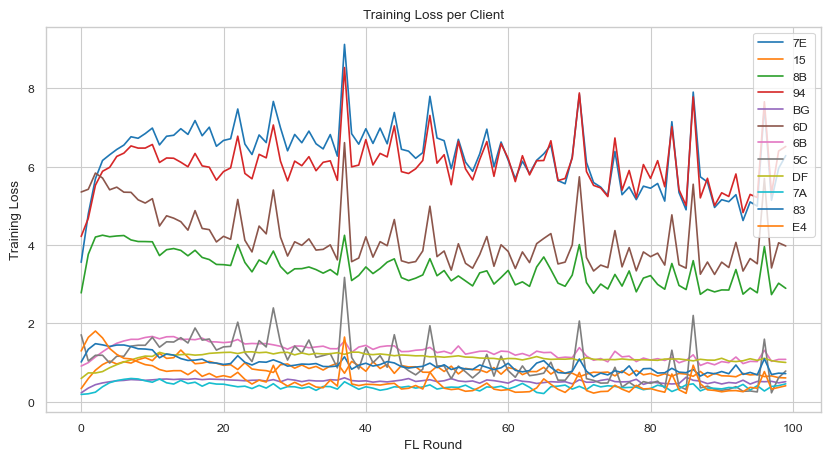

In [6]:
# Create figure once before the loop
plt.figure(figsize=(10, 5))

for client_name, client_data in clients.items():
    training_loss = [data["scores"]["training_set"]["loss"] for data in client_data["round"].values()]
    sns.lineplot(training_loss, label=client_name)

plt.xlabel("FL Round")
plt.ylabel("Training Loss")
plt.title("Training Loss per Client")
plt.legend()
plt.show()

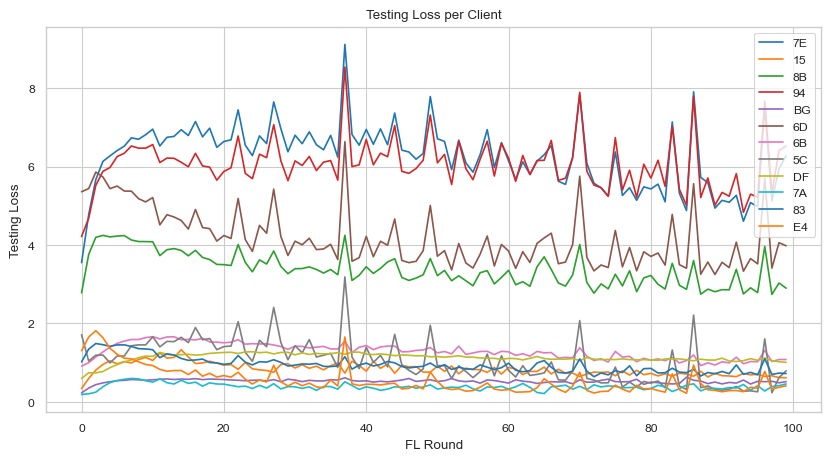

In [47]:
from matplotlib import pyplot as plt

# Create figure once before the loop
plt.figure(figsize=(10, 5))

for client_name, client_data in clients.items():
    testing_loss = [data["scores"]["testing_set"]["loss"] for data in client_data["round"].values()]
    sns.lineplot(testing_loss, label=client_name)

plt.xlabel("FL Round")
plt.ylabel("Testing Loss")
plt.title("Testing Loss per Client")
plt.legend()
plt.show()

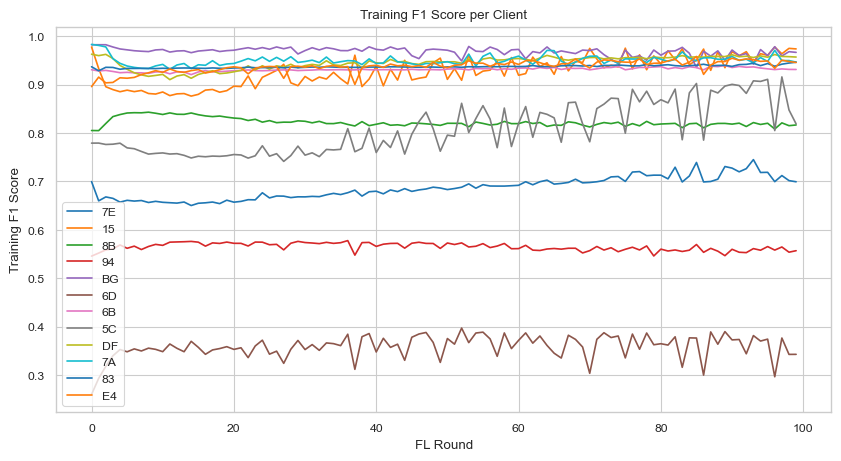

In [48]:
from matplotlib import pyplot as plt

# Create figure once before the loop
plt.figure(figsize=(10, 5))

for client_name, client_data in clients.items():
    training_f1 = [data["scores"]["training_set"]["f1"] for data in client_data["round"].values()]
    sns.lineplot(training_f1, label=client_name)

plt.xlabel("FL Round")
plt.ylabel("Training F1 Score")
plt.title("Training F1 Score per Client")
plt.legend()
plt.show()

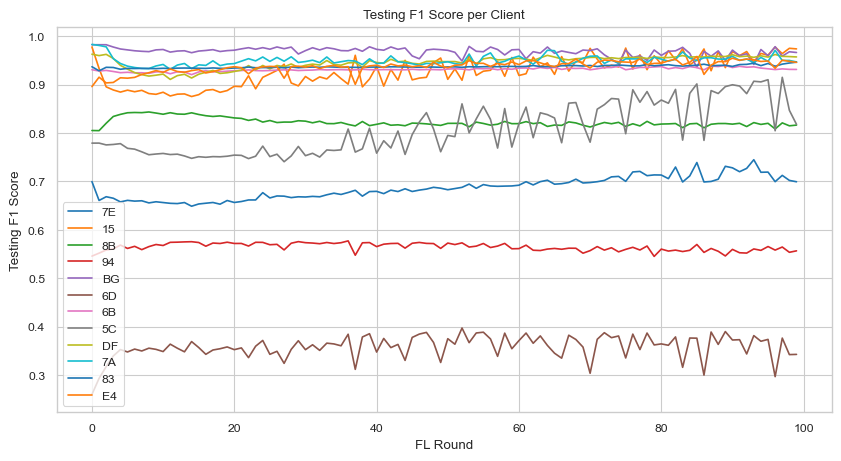

In [49]:
from matplotlib import pyplot as plt

# Create figure once before the loop
plt.figure(figsize=(10, 5))

for client_name, client_data in clients.items():
    testing_f1 = [data["scores"]["testing_set"]["f1"] for data in client_data["round"].values()]
    sns.lineplot(testing_f1, label=client_name)

plt.xlabel("FL Round")
plt.ylabel("Testing F1 Score")
plt.title("Testing F1 Score per Client")
plt.legend()
plt.show()

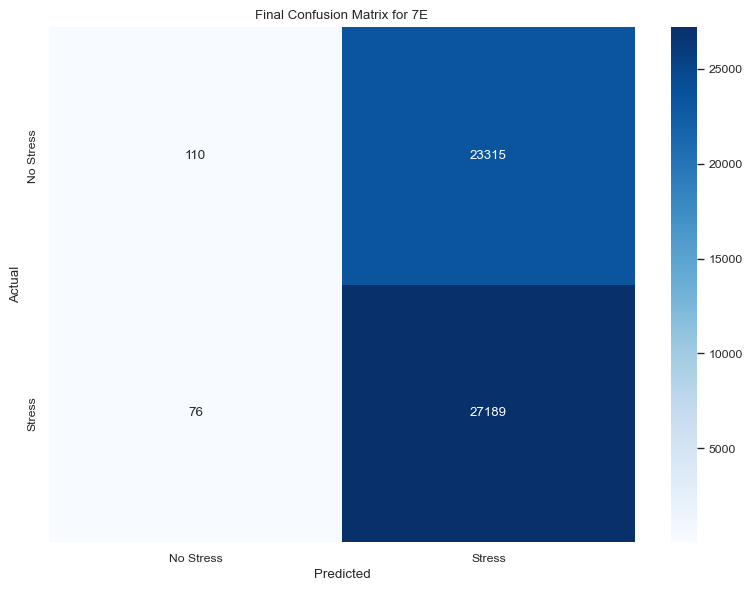

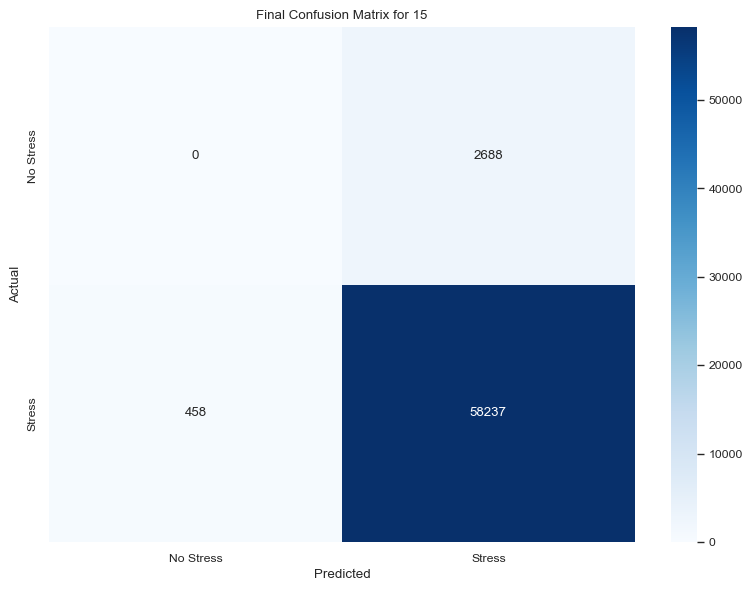

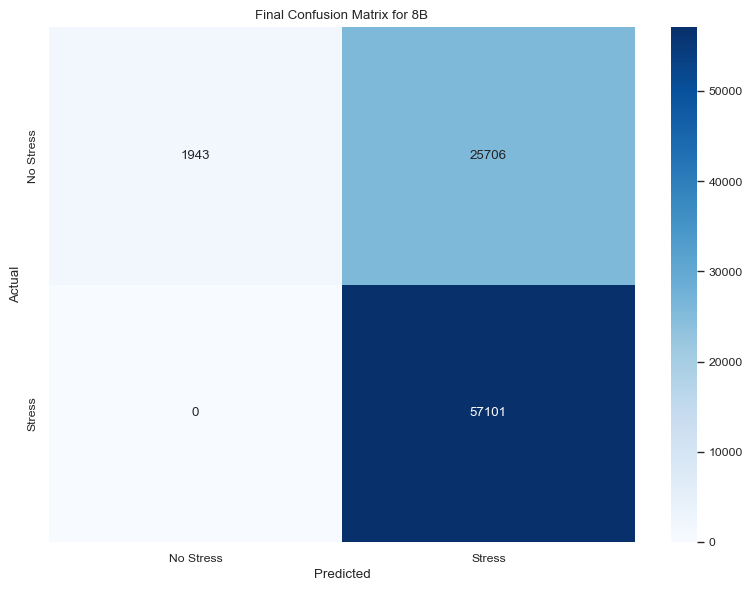

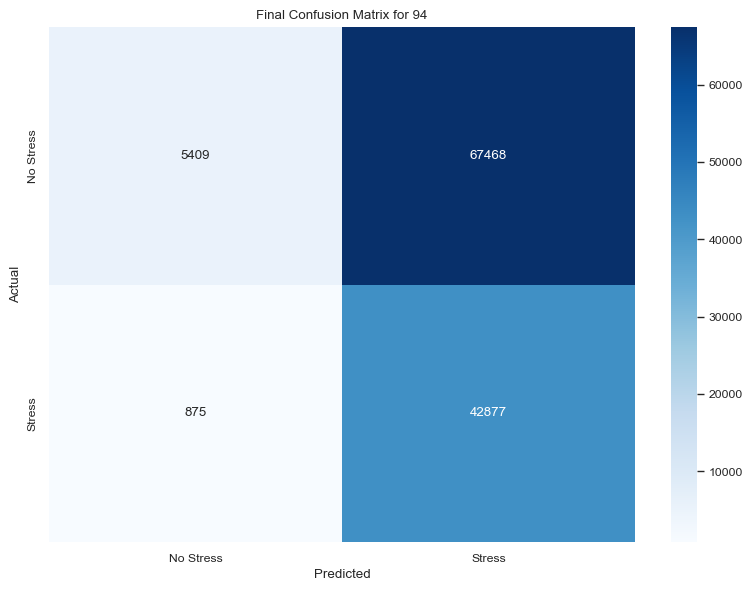

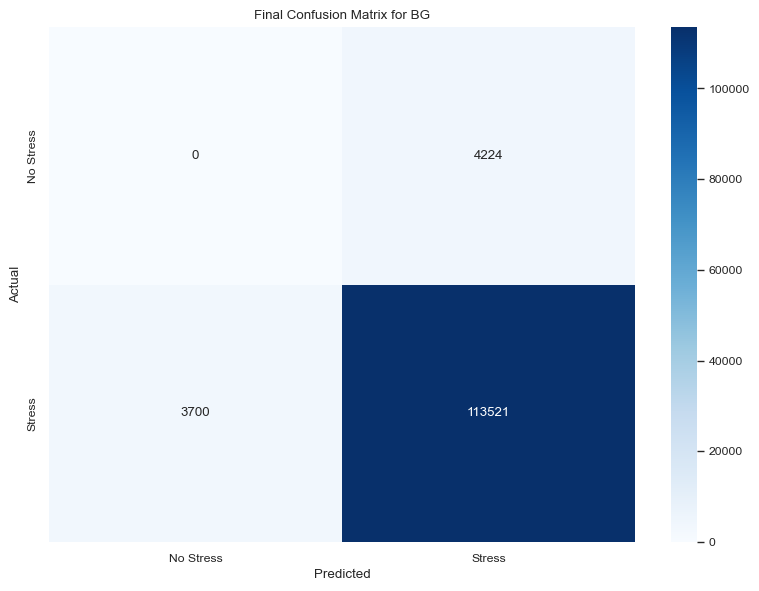

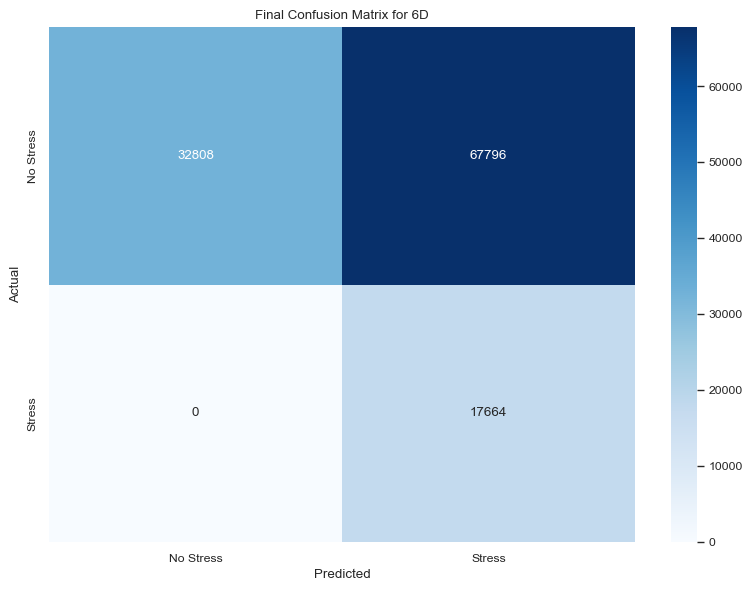

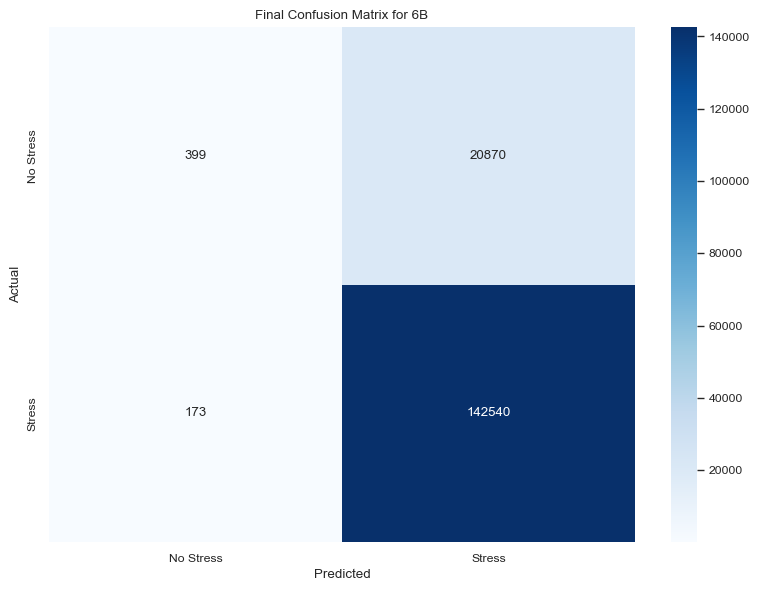

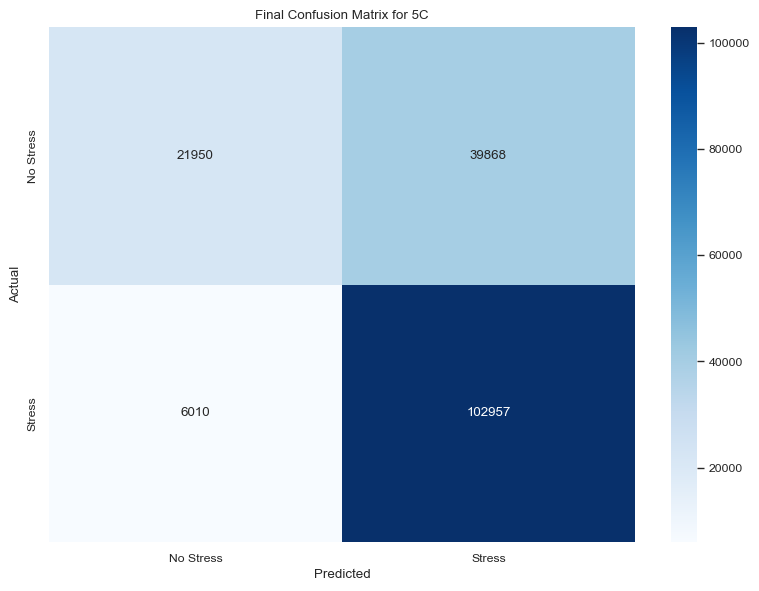

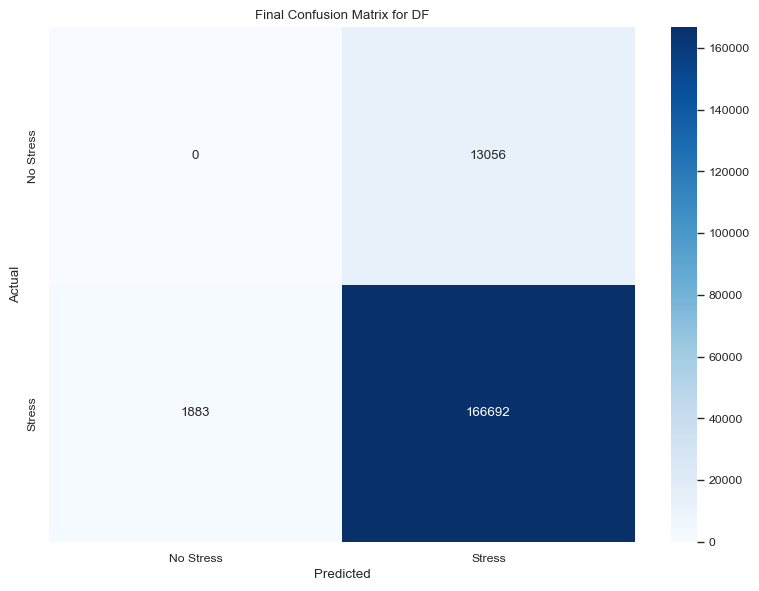

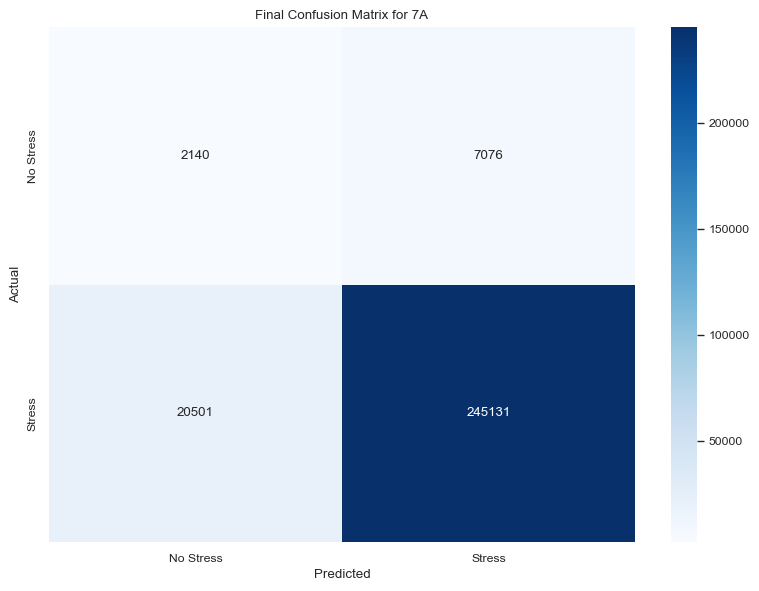

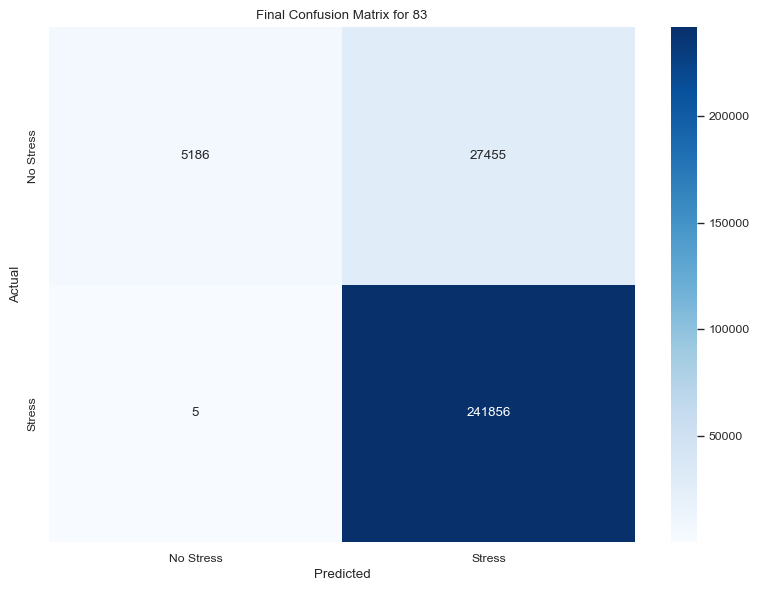

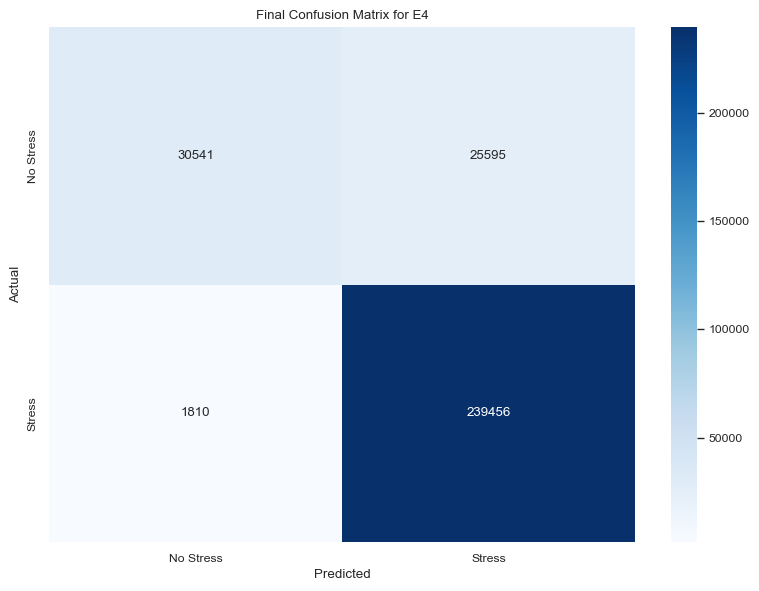

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

for client_name, client_data in clients.items():
    matrix = client_data["round"]["100"]["scores"]["testing_set"]["confusion_matrix"]
    # Assemble the confusion matrix from tp, tn, fp, fn
    conf_matrix = np.array([
        [matrix["tn"], matrix["fp"]],  # First row: actual negatives
        [matrix["fn"], matrix["tp"]]   # Second row: actual positives
    ])

    labels = ["No Stress", "Stress"]  # You can replace with your actual class names

    # Alternative with seaborn for more customization
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Final Confusion Matrix for ' + client_name)
    plt.tight_layout()
    plt.show()

## Server Side

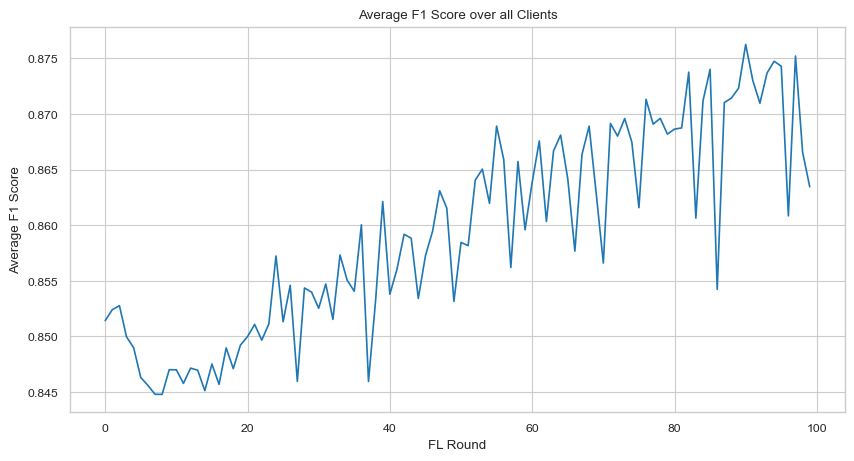

In [51]:
from matplotlib import pyplot as plt

# Create figure once before the loop
plt.figure(figsize=(10, 5))

server_data = server["distributed"]
average_f1 = [score["scores"] for score in server_data["round"].values()]
sns.lineplot(average_f1)
plt.xlabel("FL Round")
plt.ylabel("Average F1 Score")
plt.title("Average F1 Score over all Clients")
plt.show()

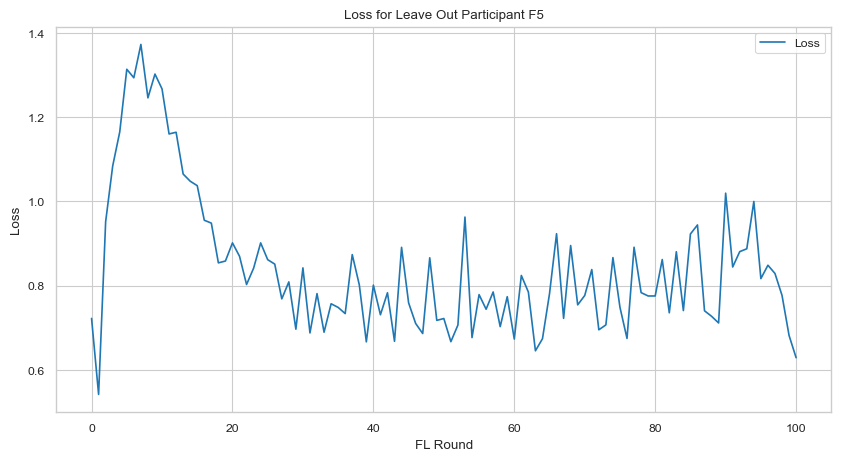

In [52]:
from matplotlib import pyplot as plt

# Create figure once before the loop
plt.figure(figsize=(10, 5))

server_data = server["centralized"]
loss = [score["scores"]["testing_set"]["loss"] for score in server_data["round"].values()]
sns.lineplot(loss, label="Loss")
plt.xlabel("FL Round")
plt.ylabel("Loss")
plt.title("Loss for Leave Out Participant F5")
plt.legend()
plt.show()

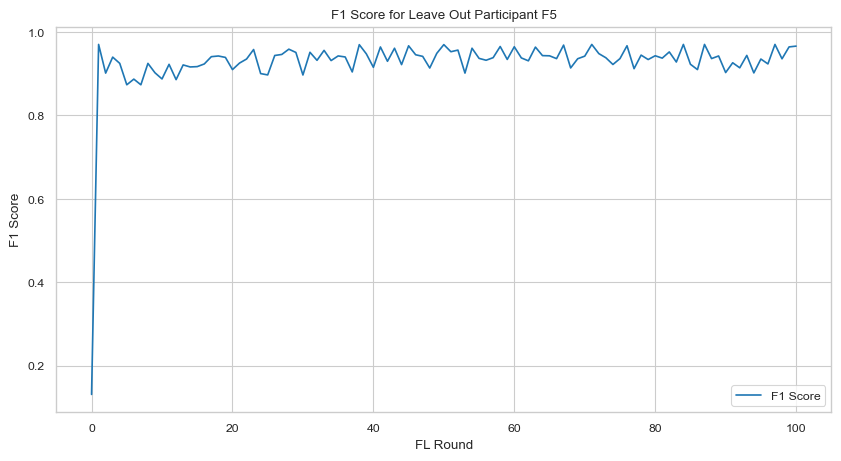

In [53]:
from matplotlib import pyplot as plt

# Create figure once before the loop
plt.figure(figsize=(10, 5))

server_data = server["centralized"]
f1 = [score["scores"]["testing_set"]["f1"] for score in server_data["round"].values()]
sns.lineplot(f1, label="F1 Score")
plt.xlabel("FL Round")
plt.ylabel("F1 Score")
plt.title("F1 Score for Leave Out Participant F5")
plt.legend()
plt.show()

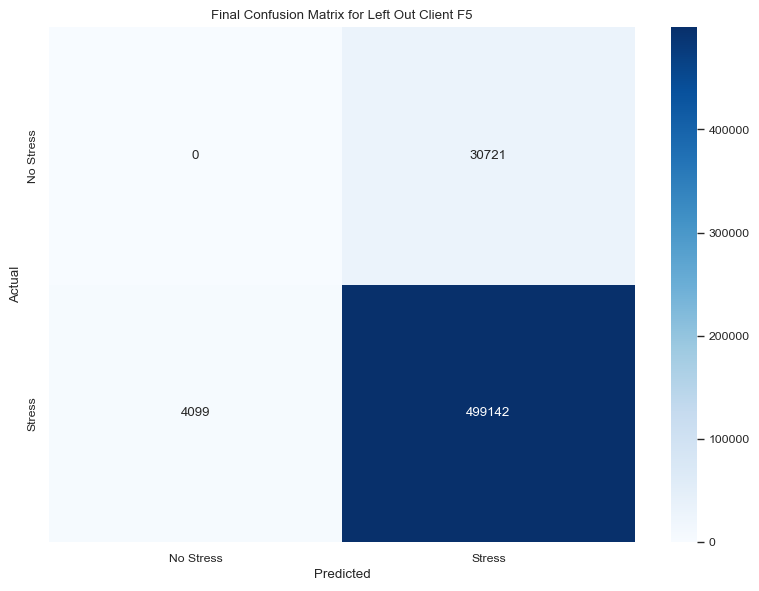

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

matrix = server["centralized"]["round"]["100"]["scores"]["testing_set"]["confusion_matrix"]
# Assemble the confusion matrix from tp, tn, fp, fn
conf_matrix = np.array([
    [matrix["tn"], matrix["fp"]],  # First row: actual negatives
    [matrix["fn"], matrix["tp"]]   # Second row: actual positives
])

# Plot the confusion matrix
labels = ["No Stress", "Stress"]  # You can replace with your actual class names

# Alternative with seaborn for more customization
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Confusion Matrix for Left Out Client F5')
plt.tight_layout()
plt.show()